In [289]:
#Telco_Customer_Churn
import pandas as pd

df = pd.read_csv("../data/Telco_Customer_Churn.csv")

In [290]:
#First few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [291]:
#Data types + missing values (combined)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [292]:
#Shape (rows and columns)
df.shape

(7043, 21)

In [293]:
#Summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [294]:
#Missing values, explicitly
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [295]:
#Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [296]:
#customerID is unique per customer, so to also check for duplicate IDs specifically
df["customerID"].duplicated().sum()

np.int64(0)

In [297]:
#Check data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [298]:
#Fix the incorrect data type (TotalCharges)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [299]:
#Re check missing values after the conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [300]:
#Drop the rows
df = df.dropna(subset=["TotalCharges"])

In [301]:
#Drop duplicates, if any were found
df = df.drop_duplicates()

In [302]:
#Final check to confirm everything is clean
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df.dtypes)

Missing values:
 0
Duplicate rows: 0
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [303]:
# Find all text columns that have exactly 2 unique categories
df = df.drop(columns=['customerID'])
binary_cols = [col for col in df.select_dtypes(include=['object', 'str']).columns
               if df[col].nunique() == 2]

for col in binary_cols:
    if set(df[col].unique()) == {'Yes', 'No'}:
        # Yes/No columns -> Yes=1, No=0
        df[col] = df[col].map({'Yes': 1, 'No': 0})
    else:
        # Other binary columns (e.g. gender) -> encode alphabetically
        categories = sorted(df[col].unique())
        df[col] = df[col].map({categories[0]: 0, categories[1]: 1})

df.to_csv('telco_churn_encoded.csv', index=False)

# Find all text columns that have exactly 3 unique categories
three_cat_cols = [col for col in df.select_dtypes(include=['object', 'str']).columns
                   if df[col].nunique() == 3]

print("3-category columns found:", three_cat_cols)
# One-hot encode them (creates a 0/1 column per category)
df = pd.get_dummies(df, columns=three_cat_cols, drop_first=False, dtype=int)

df.to_csv('telco_churn_encoded_v2.csv', index=False)

# One-hot encode PaymentMethod (4 nominal categories)
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=False, dtype=int)

df.to_csv('telco_churn_payment_encoded.csv', index=False)

3-category columns found: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']


In [304]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
OnlineSecurity_No internet service           int64
OnlineSecurity_Yes                           int64
OnlineBackup_No                

In [305]:
df["Churn"].unique()

array([0, 1])

In [306]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [307]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 40)
y shape: (7032,)


In [308]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [309]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 40)
X_test: (1407, 40)
y_train: (5625,)
y_test: (1407,)


In [310]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [311]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [312]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [313]:
#K-nearest neighbour
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

In [314]:
#Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

In [315]:
#xg boost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [316]:
#Compare all models at once
#accuracy
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Decision Tree": accuracy_score(y_test, tree_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "XG boost": accuracy_score(y_test, xgb_pred)
}

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")



Logistic Regression: 0.7882
Decision Tree: 0.7193
Random Forest: 0.7818
KNN: 0.7711
SVM: 0.7342
XG boost: 0.7754


In [317]:
from sklearn.metrics import classification_report
print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("Decision Tree")
print(classification_report(y_test, tree_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("KNN")
print(classification_report(y_test, knn_pred))

print("SVM")
print(classification_report(y_test, svm_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.47      0.49      0.48       374

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.72      0.72      1407

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77   

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

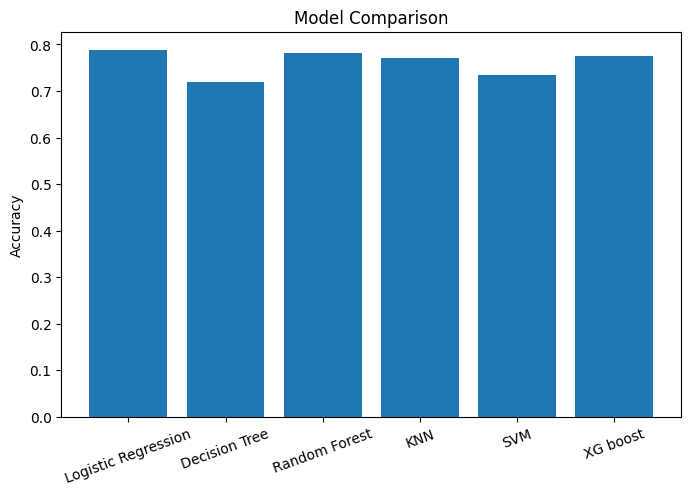

In [318]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [319]:
"""Six machine learning algorithms were trained and evaluated: 
Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and XGBoost. 
Based on accuracy, precision, recall, and F1-score,
Logistic Regression performed the best with an accuracy of 79% and the highest F1-score (0.56) for the churn class. 
Therefore, Logistic Regression was selected as the final model for predicting customer churn."""

'Six machine learning algorithms were trained and evaluated: \nLogistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and XGBoost. \nBased on accuracy, precision, recall, and F1-score,\nLogistic Regression performed the best with an accuracy of 79% and the highest F1-score (0.56) for the churn class. \nTherefore, Logistic Regression was selected as the final model for predicting customer churn.'

In [321]:
import joblib

joblib.dump(log_model, "../models/logistic_regression_model.pkl")

['../models/logistic_regression_model.pkl']

In [322]:
import joblib

loaded_model = joblib.load("../models/logistic_regression_model.pkl")

print(type(loaded_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [324]:
import joblib

model = joblib.load("../models/logistic_regression_model.pkl")

print(model)

LogisticRegression(max_iter=5000, random_state=42)


In [325]:
pred = model.predict(X_test)

print(pred[:10])

[0 0 1 0 0 0 0 1 0 0]
